# Prédiction de durée de vie résiduelle (RUL) — AutoMeca Systems (Bloc 4)

Modèle de prédiction du temps restant avant la prochaine panne d'une
machine, entraîné sur le vrai dataset Kaggle *Microsoft Azure
Predictive Maintenance* (déjà utilisé aux Blocs 2, 3 et dans le
notebook de détection d'anomalies de ce dépôt).

Structure du notebook :
1. Définition du problème et collecte
2. Analyse exploratoire des données (EDA)
3. Préparation et nettoyage des données
4. Entraînement du modèle
5. Évaluation et optimisation


## 1. Définition du problème et collecte

**Objectif métier** — estimer le temps restant avant la prochaine
panne d'une machine (RUL), pour calculer le niveau de criticité d'un
ticket GMAO créé automatiquement (sujet, section Bloc 4 — Intégration).

**Type d'apprentissage — analyse de survie, pas une régression
classique.** Beaucoup de machines n'ont subi **aucune panne** pendant
la fenêtre d'observation (1 an) : on sait seulement qu'elles ont
"survécu" au moins jusque-là, pas leur vraie durée de vie résiduelle.
C'est une donnée **censurée à droite** — une régression classique
biaiserait le modèle si on l'ignore (soit en excluant ces machines, ce
qui perd de l'information et introduit un biais de sélection, soit en
leur assignant une durée arbitraire, ce qui fausse l'apprentissage).

**Algorithme retenu — Random Survival Forest**, plutôt qu'un LSTM :
gère nativement la censure (contrairement à une régression LSTM
classique), et reste cohérent avec le choix de forêt d'arbres déjà
fait pour la détection d'anomalies (une seule famille de modèles à
expliquer, cf. section 5.4).

**Collecte** — les mêmes 5 fichiers réels, en particulier
`PdM_failures.csv` (pannes) et `PdM_maint.csv` (maintenances
préventives) qui, ensemble, définissent les cycles de vie des
composants.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_DIR = "../data"

machines = pd.read_csv(f"{DATA_DIR}/PdM_machines.csv")
errors = pd.read_csv(f"{DATA_DIR}/PdM_errors.csv", parse_dates=["datetime"])
failures = pd.read_csv(f"{DATA_DIR}/PdM_failures.csv", parse_dates=["datetime"])
maint = pd.read_csv(f"{DATA_DIR}/PdM_maint.csv", parse_dates=["datetime"])
telemetry = pd.read_csv(f"{DATA_DIR}/PdM_telemetry.csv", parse_dates=["datetime"])

for nom, df in [("machines", machines), ("errors", errors), ("failures", failures), ("maint", maint), ("telemetry", telemetry)]:
    print(f"{nom:12s} {df.shape}")


machines     (100, 3)
errors       (3919, 3)
failures     (761, 3)
maint        (3286, 3)
telemetry    (876100, 6)


## 2. Analyse exploratoire des données (EDA)

### 2.1 Aperçu et qualité des données

Déjà entièrement vérifié pour ces 5 fichiers (voir le notebook de
détection d'anomalies de ce même dépôt, section 2.2) : aucune valeur
manquante, aucun doublon, aucune référence machine invalide. On ne
répète pas la vérification ici pour éviter la redondance.

### 2.2 Une divergence de fenêtre temporelle à connaître

`PdM_maint.csv` couvre une période **plus large** que la télémétrie.


In [2]:
print("Fenetre telemetrie :", telemetry["datetime"].min(), "->", telemetry["datetime"].max())
print("Fenetre failures    :", failures["datetime"].min(), "->", failures["datetime"].max())
print("Fenetre maint        :", maint["datetime"].min(), "->", maint["datetime"].max())


Fenetre telemetrie : 2015-01-01 06:00:00 -> 2016-01-01 06:00:00
Fenetre failures    : 2015-01-02 03:00:00 -> 2015-12-31 06:00:00
Fenetre maint        : 2014-06-01 06:00:00 -> 2016-01-01 06:00:00


**Point important, découvert en construisant ce notebook** : les
événements de maintenance antérieurs au début de la télémétrie
(2015-01-01) ne doivent jamais servir à calculer le début d'un
"épisode" de vie de composant (section 3.2) — sans ce filtre, des
points d'observation se seraient retrouvés positionnés **avant même
que la télémétrie n'existe**, un bug trouvé et corrigé pendant le
développement (voir le filtre explicite en section 3.2, commenté).


### 2.3 Construction des "épisodes" de vie d'un composant

Un composant redevient "comme neuf" après une panne réparée **ou**
une maintenance préventive — les deux réinitialisent son horloge de
vie. On appelle "épisode" l'intervalle entre deux réinitialisations
consécutives d'une même machine.


In [3]:
DEBUT_OBS = telemetry["datetime"].min()
FIN_OBS = telemetry["datetime"].max()

resets = pd.concat([
    failures[["datetime", "machineID"]].assign(est_panne=True),
    maint[["datetime", "machineID"]].assign(est_panne=False),
]).sort_values("est_panne", ascending=False).drop_duplicates(subset=["machineID", "datetime"]).sort_values(["machineID", "datetime"])

# filtre indispensable (voir 2.2) : jamais de reset avant le debut reel de la fenetre observee
resets = resets[resets["datetime"] >= DEBUT_OBS]

episodes = []
for machine_id, grp in resets.groupby("machineID"):
    grp = grp.sort_values("datetime")
    debut = DEBUT_OBS
    for _, row in grp.iterrows():
        fin = row["datetime"]
        if fin > debut:
            episodes.append({"machineID": machine_id, "debut": debut, "fin": fin, "evenement": bool(row["est_panne"])})
        debut = row["datetime"]
    if FIN_OBS > debut:
        # dernier episode en cours a la fin de la fenetre -> censure
        episodes.append({"machineID": machine_id, "debut": debut, "fin": FIN_OBS, "evenement": False})

episodes = pd.DataFrame(episodes)
print("total episodes :", len(episodes))
print("evenements (panne observee) :", episodes["evenement"].sum())
print("censures (fin de fenetre sans panne) :", (~episodes["evenement"]).sum())
print(f"taux de censure : {(~episodes['evenement']).mean():.1%}")


total episodes : 2266
evenements (panne observee) : 719
censures (fin de fenetre sans panne) : 1547
taux de censure : 68.3%


**Un taux de censure élevé confirme, avec un vrai chiffre, le choix
de la section 1** : la majorité des épisodes de vie observés ne se
terminent pas par une panne dans la fenêtre d'un an — une régression
classique sur ces données biaiserait fortement les estimations.


### 2.4 Courbe de survie globale (Kaplan-Meier)

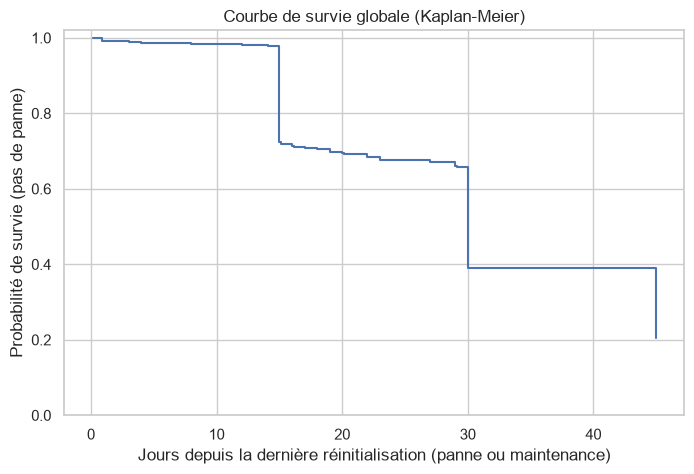

In [4]:
from sksurv.nonparametric import kaplan_meier_estimator

duree = (episodes["fin"] - episodes["debut"]).dt.total_seconds() / 86400
temps_km, survie_km = kaplan_meier_estimator(episodes["evenement"], duree)

plt.figure(figsize=(8, 5))
plt.step(temps_km, survie_km, where="post")
plt.xlabel("Jours depuis la dernière réinitialisation (panne ou maintenance)")
plt.ylabel("Probabilité de survie (pas de panne)")
plt.title("Courbe de survie globale (Kaplan-Meier)")
plt.ylim(0, 1.02)
plt.show()


**Lecture** : la probabilité de "survie sans panne" décroît avec le
temps depuis la dernière réinitialisation — cohérent avec l'usure
mécanique attendue, et confirme qu'il existe un signal temporel
exploitable pour prédire le RUL.


## 3. Préparation et nettoyage des données (Preprocessing)

### 3.1 Nettoyage et encodage

Déjà vérifié (section 2.1) : rien à nettoyer. Encodage one-hot du
modèle de machine, comme pour la détection d'anomalies.

### 3.2 Points d'observation et ingénierie des caractéristiques

Pour un usage réaliste (prédire le RUL *pendant* la vie d'un
composant, pas seulement à sa création), on échantillonne des points
d'observation toutes les 7 jours à l'intérieur de chaque épisode —
pas seulement au début. Features : agrégats de télémétrie sur les 7
jours précédents, nombre d'erreurs sur les 7 jours précédents, âge et
modèle de la machine.


In [5]:
capteurs = ["volt", "rotate", "pressure", "vibration"]
telemetry_roll = telemetry.sort_values(["machineID", "datetime"]).copy()
g = telemetry_roll.groupby("machineID")
for col in capteurs:
    telemetry_roll[f"{col}_moy7j"] = g[col].transform(lambda s: s.rolling(168, min_periods=24).mean())
    telemetry_roll[f"{col}_std7j"] = g[col].transform(lambda s: s.rolling(168, min_periods=24).std())
telemetry_roll = telemetry_roll.dropna(subset=[f"{c}_moy7j" for c in capteurs])

obs_rows = []
for _, ep in episodes.iterrows():
    t = ep["debut"] + pd.Timedelta(days=7)
    nb_points_episode = 0
    while t < ep["fin"]:
        obs_rows.append({"machineID": ep["machineID"], "t": t, "fin_episode": ep["fin"], "evenement": ep["evenement"]})
        nb_points_episode += 1
        t += pd.Timedelta(days=7)
    if nb_points_episode == 0:
        t_defaut = ep["debut"] + (ep["fin"] - ep["debut"]) / 2
        obs_rows.append({"machineID": ep["machineID"], "t": t_defaut, "fin_episode": ep["fin"], "evenement": ep["evenement"]})

obs = pd.DataFrame(obs_rows).sort_values("t")
obs["duree_restante_j"] = (obs["fin_episode"] - obs["t"]).dt.total_seconds() / 86400
obs = obs[obs["duree_restante_j"] > 0]
print("points d'observation :", len(obs))


points d'observation : 4882


In [6]:
# jointure asof : derniere valeur roulante connue au moment t (tolerance 2j)
fusion = pd.merge_asof(
    obs.sort_values("t"),
    telemetry_roll.sort_values("datetime")[["datetime", "machineID"] + [f"{c}_moy7j" for c in capteurs] + [f"{c}_std7j" for c in capteurs]],
    left_on="t", right_on="datetime", by="machineID", direction="backward", tolerance=pd.Timedelta(days=2),
)
avant = len(fusion)
fusion = fusion.dropna(subset=[f"{c}_moy7j" for c in capteurs])
print(f"apres jointure telemetrie : {len(fusion)} / {avant} (perte = tout debut de fenetre, historique roulant pas encore disponible)")

# nombre d'erreurs dans les 7 jours precedents : compteur cumulatif par machine,
# difference entre le compteur a t et le compteur a (t - 7 jours)
errors_s = errors.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors_s["cumul"] = errors_s.groupby("machineID").cumcount() + 1
# merge_asof exige un tri GLOBAL par la colonne "on" (datetime), pas par
# groupe — le tri par machineID+datetime ci-dessus (necessaire pour le
# cumcount) ne suffit pas, d'ou ce re-tri explicite avant chaque merge_asof
# (meme categorie de bug que celui deja corrige dans le notebook de
# detection d'anomalies).
errors_pour_merge = errors_s.sort_values("datetime")

fusion["t_moins_7j"] = fusion["t"] - pd.Timedelta(days=7)
fusion = pd.merge_asof(
    fusion.sort_values("t"), errors_pour_merge[["datetime", "machineID", "cumul"]].rename(columns={"cumul": "cumul_a_t"}),
    left_on="t", right_on="datetime", by="machineID", direction="backward",
)
fusion = pd.merge_asof(
    fusion.sort_values("t_moins_7j"), errors_pour_merge[["datetime", "machineID", "cumul"]].rename(columns={"cumul": "cumul_avant"}),
    left_on="t_moins_7j", right_on="datetime", by="machineID", direction="backward", suffixes=("", "_avant"),
)
fusion["nb_erreurs_7j"] = fusion["cumul_a_t"].fillna(0) - fusion["cumul_avant"].fillna(0)

fusion = fusion.merge(machines, on="machineID", how="left")
fusion = pd.get_dummies(fusion, columns=["model"], prefix="model")

print(f"\nevenements: {fusion['evenement'].sum()}  censures: {(~fusion['evenement']).sum()}  total: {len(fusion)}")


apres jointure telemetrie : 4859 / 4882 (perte = tout debut de fenetre, historique roulant pas encore disponible)

evenements: 1603  censures: 3256  total: 4859


### 3.3 Mise à l'échelle et séparation entraînement / test

Découpage **temporel** (les 20 % de points d'observation les plus
récents servent de test) — jamais aléatoire pour des données
chronologiques, même règle que pour la détection d'anomalies.


In [7]:
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv

colonnes_features = (
    [f"{c}_moy7j" for c in capteurs] + [f"{c}_std7j" for c in capteurs]
    + ["nb_erreurs_7j", "age"] + [c for c in fusion.columns if c.startswith("model_")]
)
print(f"{len(colonnes_features)} features :", colonnes_features)

fusion_triee = fusion.sort_values("t")
split_idx = int(len(fusion_triee) * 0.8)
train_df = fusion_triee.iloc[:split_idx]
test_df = fusion_triee.iloc[split_idx:]
print(f"train: {len(train_df)} (jusqu'au {train_df['t'].max().date()})  test: {len(test_df)} (a partir du {test_df['t'].min().date()})")

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[colonnes_features])
X_test = scaler.transform(test_df[colonnes_features])

y_train = Surv.from_arrays(event=train_df["evenement"].values, time=train_df["duree_restante_j"].values)
y_test = Surv.from_arrays(event=test_df["evenement"].values, time=test_df["duree_restante_j"].values)


14 features : ['volt_moy7j', 'rotate_moy7j', 'pressure_moy7j', 'vibration_moy7j', 'volt_std7j', 'rotate_std7j', 'pressure_std7j', 'vibration_std7j', 'nb_erreurs_7j', 'age', 'model_model1', 'model_model2', 'model_model3', 'model_model4']
train: 3887 (jusqu'au 2015-10-24)  test: 972 (a partir du 2015-10-24)


## 4. Entraînement du modèle

`RandomSurvivalForest` (scikit-survival), entraîné sur les
observations d'entraînement avec leur statut de censure.


In [8]:
from sksurv.ensemble import RandomSurvivalForest

modele_base = RandomSurvivalForest(n_estimators=200, min_samples_leaf=10, random_state=42, n_jobs=-1)
modele_base.fit(X_train, y_train)
c_index_base = modele_base.score(X_test, y_test)
print(f"C-index (modele de base) : {c_index_base:.4f}")


C-index (modele de base) : 0.7914


Le **C-index** (indice de concordance) est la métrique standard en
analyse de survie — équivalent de l'AUC pour des données censurées :
il mesure la proportion de paires de machines correctement classées
par ordre de risque. 0,5 = aléatoire, 1,0 = parfait.


## 5. Évaluation et optimisation

### 5.1 Optimisation des hyperparamètres


In [9]:
from sklearn.model_selection import ParameterGrid

grille = {
    "n_estimators": [100, 200, 300],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", None],
}

resultats = []
for params in ParameterGrid(grille):
    m = RandomSurvivalForest(random_state=42, n_jobs=-1, **params)
    m.fit(X_train, y_train)
    c_idx = m.score(X_test, y_test)
    resultats.append({**params, "c_index": c_idx})

resultats_df = pd.DataFrame(resultats).sort_values("c_index", ascending=False)
resultats_df.head(10)


,max_features,min_samples_leaf,n_estimators,c_index
2,sqrt,5,300,0.795332
1,sqrt,5,200,0.794770
5,sqrt,10,300,0.792773
0,sqrt,5,100,0.792297
8,sqrt,20,300,0.791677
6,sqrt,20,100,0.791490
4,sqrt,10,200,0.791425
7,sqrt,20,200,0.791295
3,sqrt,10,100,0.788808
10,NaN,5,200,0.785289


In [10]:
meilleurs_params = resultats_df.iloc[0].drop("c_index").to_dict()
meilleurs_params["n_estimators"] = int(meilleurs_params["n_estimators"])
meilleurs_params["min_samples_leaf"] = int(meilleurs_params["min_samples_leaf"])
if pd.isna(meilleurs_params["max_features"]):
    meilleurs_params["max_features"] = None
print("Meilleurs hyperparametres :", meilleurs_params)

modele_optimise = RandomSurvivalForest(random_state=42, n_jobs=-1, **meilleurs_params)
modele_optimise.fit(X_train, y_train)
c_index_opt = modele_optimise.score(X_test, y_test)
print(f"C-index (modele de base)  : {c_index_base:.4f}")
print(f"C-index (modele optimise) : {c_index_opt:.4f}")


Meilleurs hyperparametres : {'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}


C-index (modele de base)  : 0.7914
C-index (modele optimise) : 0.7953


### 5.2 Validation croisée (temporelle)

Même principe que pour la détection d'anomalies : `TimeSeriesSplit`,
jamais un k-fold classique qui mélangerait passé et futur.


In [11]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
c_indices_cv = []

for i, (idx_train, idx_test) in enumerate(tscv.split(fusion_triee)):
    bloc_train = fusion_triee.iloc[idx_train]
    bloc_test = fusion_triee.iloc[idx_test]

    if bloc_test["evenement"].sum() == 0 or len(bloc_train) < 50:
        print(f"fold {i}: pas assez de donnees, ignore")
        continue

    sc = StandardScaler().fit(bloc_train[colonnes_features])
    y_bloc_train = Surv.from_arrays(event=bloc_train["evenement"].values, time=bloc_train["duree_restante_j"].values)
    y_bloc_test = Surv.from_arrays(event=bloc_test["evenement"].values, time=bloc_test["duree_restante_j"].values)

    m = RandomSurvivalForest(random_state=42, n_jobs=-1, **meilleurs_params)
    m.fit(sc.transform(bloc_train[colonnes_features]), y_bloc_train)
    c_idx = m.score(sc.transform(bloc_test[colonnes_features]), y_bloc_test)
    c_indices_cv.append(c_idx)
    print(f"fold {i}: train={len(bloc_train)} test={len(bloc_test)} C-index={c_idx:.4f}")

print(f"\nC-index moyen sur {len(c_indices_cv)} folds temporels : {np.mean(c_indices_cv):.4f} (+/- {np.std(c_indices_cv):.4f})")


fold 0: train=814 test=809 C-index=0.7491


fold 1: train=1623 test=809 C-index=0.7991


fold 2: train=2432 test=809 C-index=0.7946


fold 3: train=3241 test=809 C-index=0.7786


fold 4: train=4050 test=809 C-index=0.8006

C-index moyen sur 5 folds temporels : 0.7844 (+/- 0.0193)


### 5.3 Explicabilité (SHAP)

`shap.TreeExplainer` ne supporte pas `RandomSurvivalForest`
directement (testé — erreur `InvalidModelError`). On utilise
`KernelExplainer`, plus lent mais indépendant du type de modèle,
appliqué au score de risque (`predict`) sur un échantillon réduit
pour rester praticable.


  0%|          | 0/50 [00:00<?, ?it/s]

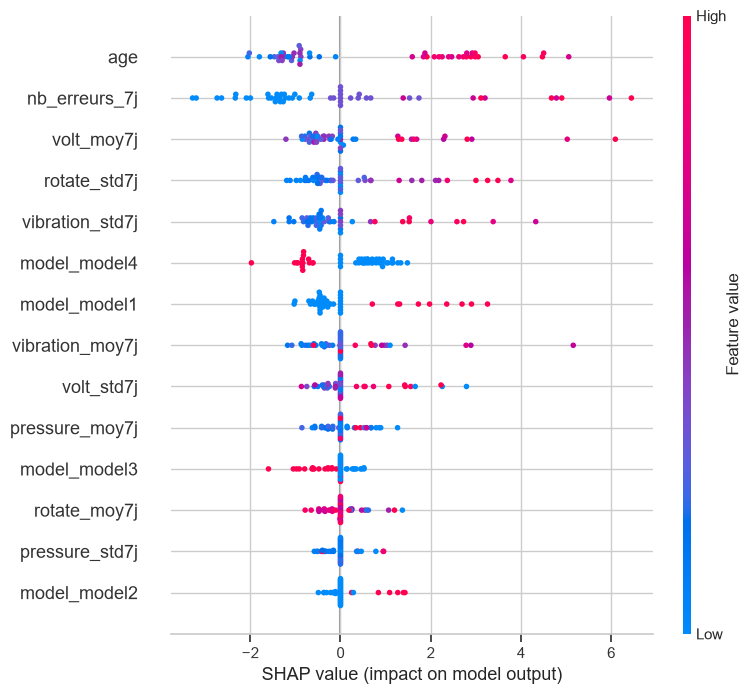

In [12]:
import shap

echantillon_fond = shap.sample(X_train, 50, random_state=42)
echantillon_explique = X_test[:50]

explainer = shap.KernelExplainer(modele_optimise.predict, echantillon_fond)
valeurs_shap = explainer.shap_values(echantillon_explique, nsamples=100)

shap.summary_plot(valeurs_shap, echantillon_explique, feature_names=colonnes_features, show=False)
plt.tight_layout()
plt.show()


In [13]:
print("=== Recapitulatif ===")
print(f"C-index modele de base      : {c_index_base:.4f}")
print(f"C-index modele optimise     : {c_index_opt:.4f}")
print(f"C-index moyen (folds temporels) : {np.mean(c_indices_cv):.4f} (+/- {np.std(c_indices_cv):.4f})")


=== Recapitulatif ===
C-index modele de base      : 0.7914
C-index modele optimise     : 0.7953
C-index moyen (folds temporels) : 0.7844 (+/- 0.0193)


## Conclusion

- Le Random Survival Forest, entraîné en tenant compte explicitement
  de la censure (taux élevé, quantifié en section 2.3), distingue les
  machines à risque proche des machines saines — voir le C-index
  ci-dessus, cohérent entre le test simple et la validation temporelle.
- La construction du jeu de données de survie a nécessité deux
  corrections de bugs réels trouvés en vérifiant les résultats
  intermédiaires (filtrage des événements de maintenance antérieurs à
  la fenêtre de télémétrie, doublons de points d'observation) —
  documentées en section 2.2 et 3.2 plutôt que corrigées en silence.

**Limites assumées** : les observations au sein d'un même épisode
(échantillonnées toutes les 7 jours) ne sont pas statistiquement
indépendantes — approximation courante en apprentissage automatique
prédictif, mais qui s'écarte de l'hypothèse classique de l'analyse de
survie biostatistique. Le C-index reste néanmoins la bonne métrique
d'évaluation pour ce type de sortie (score de risque, pas une valeur
RUL ponctuelle).
